### Задание.

В файле *immunology_dataset.csv* представлены иммунологические данные для трех групп людей (переменная Group):

- Здоровые (Healthy)  
- Пациенты с аутоиммунным заболеванием (Autoimmune)  
- Пациенты с  онкологическим заболеванием (Cancer)  

Для каждого пациента измерены следующие показатели:  
- Пол (Gender) — категориальная переменная (M/F)  
- Возраст (Age) — количественная переменная (годы)  
- Индекс массы тела (BMI) — количественная переменная  
- Уровень экспрессии гена IL6 (IL6_expression) — количественная переменная  
- Уровень экспрессии гена TNFα (TNF_expression) — количественная переменная  
- Уровень С-реактивного белка (CRP) — количественная переменная (мг/л)  
- Количество лейкоцитов (WBC) — количественная переменная (тыс/мкл)  
- Наличие аутоантител (Autoantibodies) — бинарная переменная  

Ответьте на следующие вопросы и выполните задания на основе представленного датасета:

1) Проверьте все количественные переменные на нормальность. Постройте для каждой рассматриваемой переменной PDF (на одном рисунке).

2) Постройте диаграммы рассеяния между переменными IL6 и TNFα, а также между переменными BMI и Age. На каждой из них раскрасьте точки разными цветами в зависимости от группы. Наблюдается ли взаимосвязь в парах указанных переменных (пока просто предположите на основе графиков)?

3) Постройте тепловую карту матрицы корреляций для всех количественных переменных. Выпишите пары переменных, для которых наблюдается положительная корреляция или отрицательная корреляция.

4) Наблюдается ли статистически значимая корреляция между уровнями экспрессии IL6 и TNFα в общем случае (рассмотреть всех людей)? Различается ли эта корреляция по группам?

5) Отличается ли уровень экспрессии IL6 между здоровыми и онкологическими пациентами?

6) Отличается ли возраст между тремя группами?

7) Наблюдается ли более высокий уровень CRP в группе аутоимунных заболеваний по сравнению со здоровой группой?

8) Наблюдается ли связь между группой и наличием аутоантител?

9) Наблюдается ли связь между полом и наличием аутоантител в группе аутоимунных заболеваний?

10) Какие из переменных (Age, BMI, IL6_expression, TNF_expression, CRP и WBC) статистически значимо отличаются между группой аутоимунных заболеваний и онкологической группой?

## 1. Загрузка данных и подготовка


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Загрузка данных
file_path = 'immunology_dataset.csv'
df = pd.read_csv(file_path)
df.head()

,Group,Gender,Age,BMI,IL6_expression,TNF_expression,CRP,WBC,Autoantibodies
0,Cancer,M,52,24.3,14.55,2.30,4.7,10.4,1
1,Autoimmune,F,21,22.6,10.75,18.85,20.1,8.1,1
2,Healthy,F,42,24.8,2.24,3.12,0.2,6.6,0
3,Cancer,M,60,21.8,8.15,7.04,4.3,13.4,0
4,Cancer,F,49,28.4,13.86,3.78,0.1,5.5,0


## 2. Проверка количественных переменных на нормальность и построение PDF

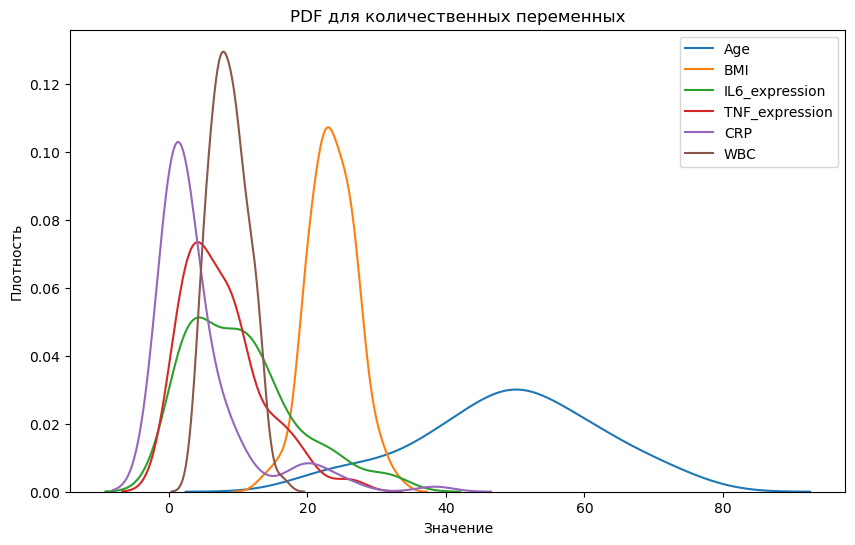

In [2]:
# Количественные переменные
num_cols = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']

# Проверка на нормальность (тест Шапиро-Уилка)
norm_results = {col: stats.shapiro(df[col]) for col in num_cols}
pd.DataFrame({k: {'stat': v.statistic, 'p-value': v.pvalue} for k, v in norm_results.items()}).T

# PDF для всех количественных переменных
plt.figure(figsize=(10, 6))
for col in num_cols:
    sns.kdeplot(df[col], label=col)
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.title('PDF для количественных переменных')
plt.legend()
plt.show()

## 3. Диаграммы рассеяния между IL6 и TNFα, а также между BMI и Age

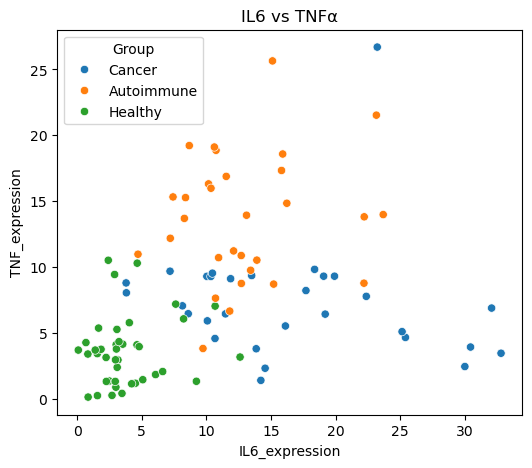

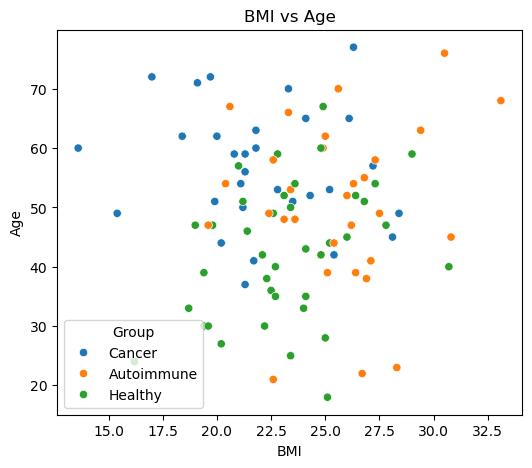

In [3]:
# Диаграмма рассеяния IL6 и TNFα
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='IL6_expression', y='TNF_expression', hue='Group')
plt.title('IL6 vs TNFα')
plt.show()

# Диаграмма рассеяния BMI и Age
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='BMI', y='Age', hue='Group')
plt.title('BMI vs Age')
plt.show()

## 4. Тепловая карта корреляций количественных переменных

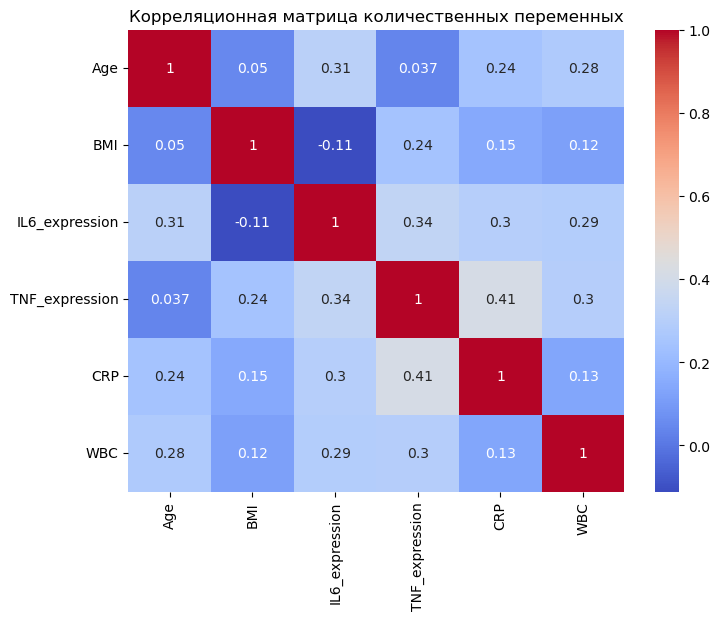

(Series([], dtype: float64), Series([], dtype: float64))

In [4]:
# Корреляционная матрица
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица количественных переменных')
plt.show()

# Пары с положительной и отрицательной корреляцией
corr_pairs = corr.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
strong_pos = corr_pairs[corr_pairs > 0.5]
strong_neg = corr_pairs[corr_pairs < -0.5]
strong_pos, strong_neg

## 5. Корреляция между IL6 и TNFα (общая и по группам)

In [5]:
# Общая корреляция
corr_all = df['IL6_expression'].corr(df['TNF_expression'])
# Корреляция по группам
group_corr = df.groupby('Group')[['IL6_expression', 'TNF_expression']].corr().iloc[0::2,-1].reset_index()
group_corr

,Group,level_1,TNF_expression
0,Autoimmune,IL6_expression,0.134049
1,Cancer,IL6_expression,-0.102764
2,Healthy,IL6_expression,0.136997


## 6. Сравнение IL6 между здоровыми и онкологическими пациентами

In [6]:
# Сравнение IL6 между Healthy и Cancer
healthy = df[df['Group'] == 'Healthy']['IL6_expression']
cancer = df[df['Group'] == 'Cancer']['IL6_expression']
# Тест Манна-Уитни (непараметрический)
stats.mannwhitneyu(healthy, cancer)

MannwhitneyuResult(statistic=np.float64(52.0), pvalue=np.float64(8.159540554362873e-11))

## 7. Сравнение возраста между тремя группами

In [7]:
# Сравнение возраста между группами (Крус-каллис)
groups = [df[df['Group'] == g]['Age'] for g in df['Group'].unique()]
stats.kruskal(*groups)

KruskalResult(statistic=np.float64(20.783082096544565), pvalue=np.float64(3.069100177049137e-05))

## 8. Сравнение CRP между Autoimmune и Healthy

In [8]:
# Сравнение CRP между Autoimmune и Healthy
auto = df[df['Group'] == 'Autoimmune']['CRP']
healthy = df[df['Group'] == 'Healthy']['CRP']
stats.mannwhitneyu(auto, healthy)

MannwhitneyuResult(statistic=np.float64(1069.0), pvalue=np.float64(2.6231222928254794e-08))

## 9. Связь между группой и наличием аутоантител

In [9]:
# Таблица сопряжённости и критерий хи-квадрат
tab = pd.crosstab(df['Group'], df['Autoantibodies'])
from scipy.stats import chi2_contingency
chi2_contingency(tab)

Chi2ContingencyResult(statistic=np.float64(29.17917917917918), pvalue=np.float64(4.6112827005185607e-07), dof=2, expected_freq=array([[18.9, 11.1],
       [18.9, 11.1],
       [25.2, 14.8]]))

## 10. Связь между полом и аутоантителами в группе аутоиммунных заболеваний

In [10]:
# Только для Autoimmune
auto = df[df['Group'] == 'Autoimmune']
tab = pd.crosstab(auto['Gender'], auto['Autoantibodies'])
chi2_contingency(tab)

Chi2ContingencyResult(statistic=np.float64(1.779714850367024), pvalue=np.float64(0.18218434506724362), dof=1, expected_freq=array([[ 5.13333333, 16.86666667],
       [ 1.86666667,  6.13333333]]))

## 11. Какие переменные статистически значимо отличаются между Autoimmune и Cancer

In [11]:
# Сравнение переменных между Autoimmune и Cancer
auto = df[df['Group'] == 'Autoimmune']
cancer = df[df['Group'] == 'Cancer']
vars_to_check = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']
results = {}
for var in vars_to_check:
    results[var] = stats.mannwhitneyu(auto[var], cancer[var])
results

{'Age': MannwhitneyuResult(statistic=np.float64(332.0), pvalue=np.float64(0.08218682560959994)),
 'BMI': MannwhitneyuResult(statistic=np.float64(692.5), pvalue=np.float64(0.00034586495138787244)),
 'IL6_expression': MannwhitneyuResult(statistic=np.float64(348.0), pvalue=np.float64(0.13345408758779304)),
 'TNF_expression': MannwhitneyuResult(statistic=np.float64(787.0), pvalue=np.float64(6.523811813545671e-07)),
 'CRP': MannwhitneyuResult(statistic=np.float64(547.0), pvalue=np.float64(0.1535471902640417)),
 'WBC': MannwhitneyuResult(statistic=np.float64(442.0), pvalue=np.float64(0.9116820881479285))}